# Hipótesis de Viralidad

**Objetivo:** Predecir si un artista tiene >70% de probabilidad de duplicar sus 'Deezer Fans' en 6 meses.

**Features (Variables predictoras):**
1. Deezer Rank actual.
2. Ratio de crecimiento de Fans (simulado por ahora).
3. Popularidad del Top Track vs. Promedio del género.

**Target (Variable a predecir):** `is_viral` (1 = Sí, 0 = No).

## Product Thinking — por qué esto importa

El dashboard responde *"¿cómo están los artistas hoy?"*. Este modelo responde *"¿quién explotará en 6 meses?"* — la pregunta que permite firmar talento **antes** de que su precio suba.

**Datos actuales:** 10 artistas reales (snapshot Deezer) — suficiente para diseñar features, NO para entrenar. La siguiente lección genera un dataset sintético de 10.000 artistas con series de tiempo; este notebook queda preparado para consumir cualquiera de las dos fuentes.

In [1]:
# Entorno del laboratorio de ML
import sys
import sklearn
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns

print(f"Python {sys.version.split()[0]}")
print(f"scikit-learn {sklearn.__version__} | pandas {pd.__version__} | numpy {np.__version__}")
print(f"matplotlib {matplotlib.__version__} | seaborn {sns.__version__}")

Python 3.10.11
scikit-learn 1.7.2 | pandas 2.3.3 | numpy 2.2.6
matplotlib 3.10.9 | seaborn 0.13.2


In [2]:
# Datos reales del warehouse (con auto-reparación si no existe)
import os
sys.path.insert(0, os.path.abspath(".."))

import duckdb
import bootstrap_db

DB_PATH = bootstrap_db.resolve_db_path()
bootstrap_db.ensure_database(DB_PATH)
bootstrap_db.ensure_table(DB_PATH)

con = duckdb.connect(DB_PATH, read_only=True)
df_real = pd.read_sql_query("SELECT * FROM artist_scouting_deezer", con)
con.close()

print(f"Artistas reales cargados: {len(df_real)}")
print(f"Warehouse: {DB_PATH}")
df_real[["artist_name", "deezer_fans", "deezer_rank", "top_track_rank", "scouting_score", "ar_recommendation"]]

Artistas reales cargados: 10
Warehouse: C:\Users\LENOVO\Desktop\BASES DE DATOS DE PRUEBAS\music_ar_product.duckdb


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27756\4282873226.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_real = pd.read_sql_query("SELECT * FROM artist_scouting_deezer", con)


,artist_name,deezer_fans,deezer_rank,top_track_rank,scouting_score,ar_recommendation
0,KAROL G,3411808,796911,974722,89.85,🔥 FIRMAR AHORA
1,Myke Towers,1705933,662773,762053,63.78,👀 OBSERVAR
2,Bizarrap,1124709,614038,796653,56.94,👀 OBSERVAR
3,Feid,905383,671329,648293,54.83,👀 OBSERVAR
4,Peso Pluma,507388,658050,775792,53.28,👀 OBSERVAR
5,Quevedo,301916,683085,754646,52.29,👀 OBSERVAR
6,Ryan Castro,310180,651442,775990,51.22,👀 OBSERVAR
7,Young Miko,136494,621015,686981,46.35,👀 OBSERVAR
8,Mora,243163,553962,618993,42.54,👀 OBSERVAR
9,SAIKO,53984,452220,536634,34.10,⚠️ DESCARTAR


## Features disponibles hoy (de los datos reales)

| Feature | Fuente | Rol en la hipótesis |
|---------|--------|---------------------|
| `deezer_rank` | API real (proxy top-10) | Feature 1: posición actual |
| `deezer_fans` | API real | Base para el ratio de crecimiento (Feature 2, con histórico) |
| `top_track_rank` | API real | Proxy de popularidad del hit (Feature 3) |
| `fan_rank_ratio` | mart dbt | Eficiencia de conversión oyente→fan |

## Pendiente (próxima lección)
- Dataset sintético de 10.000 artistas con variables de tiempo.
- Construcción del target `is_viral` (duplicación de fans en 6 meses).
- Baseline: Regresión Logística → luego Random Forest / XGBoost.

# Laboratorio: Predicción de Viralidad (Random Forest)

Dataset sintético de 10.000 artistas emergentes → **Viral Probability Score** por artista. Ejecutado end-to-end; las salidas quedan embebidas como evidencia.

In [3]:
%matplotlib inline
# Celda 1: Importar Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Entorno listo para el laboratorio de ML")

Entorno listo para el laboratorio de ML


In [4]:
# Celda 2: Generar Dataset Sintético Realista (10,000 Artistas)
# 💡 Lección del Decano: en la vida real, a veces debes simular datos históricos
# para prototipar antes de que la empresa te dé acceso a su base de datos privada.
np.random.seed(42)
n_artistas = 10000

# 1. Features (Variables predictoras)
generos = ['Urbano', 'Pop', 'Indie', 'Electrónica', 'Folk']
genero_encoded = np.random.choice([0, 1, 2, 3, 4], n_artistas)  # Label encoding simple

current_fans = np.random.lognormal(mean=8, sigma=1.5, size=n_artistas).astype(int)  # Distribución realista (cola larga)
current_rank = np.random.randint(10000, 1000000, n_artistas)  # Rank en Deezer (menor es mejor)
track_rank = np.random.randint(50000, 1000000, n_artistas)  # Rank del top track
monthly_growth_rate = np.random.uniform(-0.05, 0.30, n_artistas)  # Crecimiento mensual (-5% a +30%)

# 2. Target (Variable a predecir): ¿Se volverá viral en 6 meses? (1 = Sí, 0 = No)
# Lógica de negocio: alta probabilidad si tiene buen crecimiento, buen rank de
# track y no es demasiado grande aún
probabilidad_viral = (
    (monthly_growth_rate > 0.15).astype(int) * 0.4 +
    (track_rank < 200000).astype(int) * 0.3 +
    (current_fans < 50000).astype(int) * 0.2 +
    (current_rank < 300000).astype(int) * 0.1
)

# Agregamos un poco de "ruido" realista (la industria musical es impredecible)
ruido = np.random.normal(0, 0.15, n_artistas)
is_viral_next_6m = (probabilidad_viral + ruido > 0.5).astype(int)

# Crear DataFrame
df_ml = pd.DataFrame({
    'genero_encoded': genero_encoded,
    'current_fans': current_fans,
    'current_rank': current_rank,
    'track_rank': track_rank,
    'monthly_growth_rate': monthly_growth_rate,
    'is_viral_next_6m': is_viral_next_6m
})

print(f"✅ Dataset generado: {df_ml.shape[0]} artistas, {df_ml.shape[1]} columnas")
print(f"Distribución del Target: {df_ml['is_viral_next_6m'].value_counts(normalize=True).round(2).to_dict()}")

✅ Dataset generado: 10000 artistas, 6 columnas
Distribución del Target: {0: 0.58, 1: 0.42}


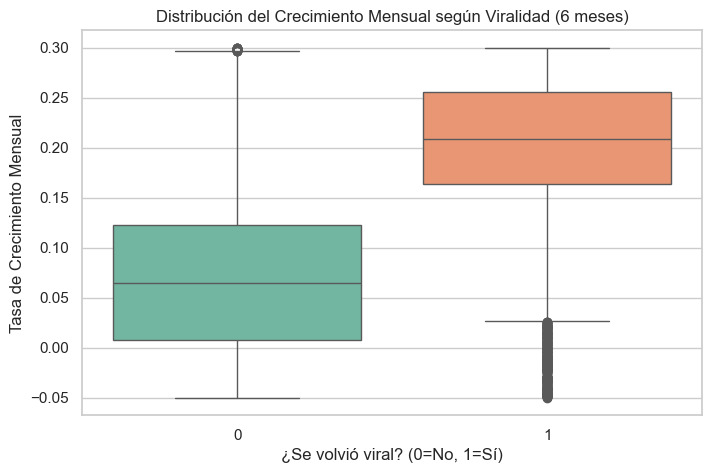

In [5]:
# Celda 3: Exploración Rápida (EDA)
# Relación entre crecimiento mensual y viralidad futura
# (fix seaborn 0.13: hue explícito para usar palette sin deprecation warning)
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_viral_next_6m', y='monthly_growth_rate', hue='is_viral_next_6m',
            data=df_ml, palette='Set2', legend=False)
plt.title('Distribución del Crecimiento Mensual según Viralidad (6 meses)')
plt.xlabel('¿Se volvió viral? (0=No, 1=Sí)')
plt.ylabel('Tasa de Crecimiento Mensual')
plt.show()

In [6]:
# Celda 4: Entrenar el Modelo (Random Forest)
# 1. Separar Features (X) y Target (y)
X = df_ml.drop('is_viral_next_6m', axis=1)
y = df_ml['is_viral_next_6m']

# 2. Dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Inicializar y entrenar el modelo
print("🤖 Entrenando Random Forest...")
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo_rf.fit(X_train, y_train)

# 4. Predecir sobre el conjunto de prueba
y_pred = modelo_rf.predict(X_test)
y_pred_proba = modelo_rf.predict_proba(X_test)[:, 1]  # Probabilidades para el ROC-AUC
print("Modelo entrenado:", modelo_rf)

🤖 Entrenando Random Forest...


Modelo entrenado: RandomForestClassifier(max_depth=5, random_state=42)


In [7]:
# Celda 5: Evaluar el Modelo (La parte que le importa al Negocio)
print("📊 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred, target_names=['No Viral', 'Viral']))

auc = roc_auc_score(y_test, y_pred_proba)
print(f"🎯 ROC-AUC Score: {auc:.4f}")
print("(Un ROC-AUC > 0.70 se considera bueno para predicciones de comportamiento humano)")

📊 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    No Viral       0.93      0.82      0.87      1167
       Viral       0.79      0.91      0.84       833

    accuracy                           0.86      2000
   macro avg       0.86      0.87      0.86      2000
weighted avg       0.87      0.86      0.86      2000

🎯 ROC-AUC Score: 0.9242
(Un ROC-AUC > 0.70 se considera bueno para predicciones de comportamiento humano)


            Feature  Importancia
monthly_growth_rate     0.769679
         track_rank     0.175933
       current_rank     0.032118
       current_fans     0.020265
     genero_encoded     0.002005


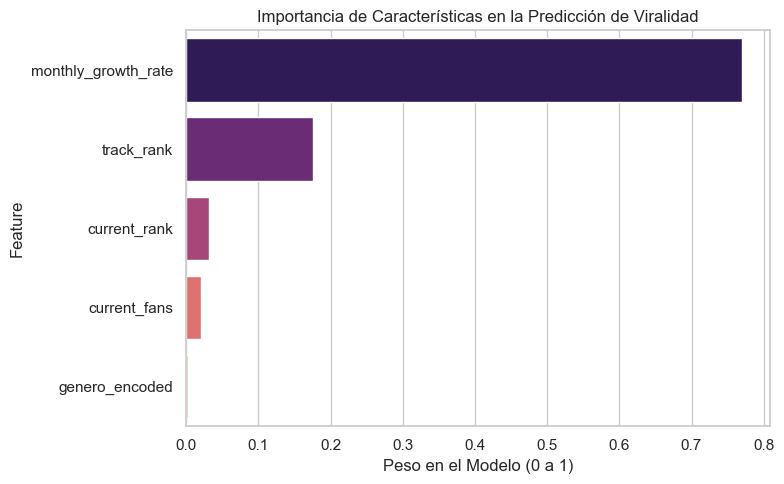

In [8]:
# Celda 6: Feature Importance (El "Por Qué" del Modelo)
# 💡 Un modelo de caja negra no sirve en A&R: el Director necesita saber QUÉ
# variables impulsan la predicción.
importancias = modelo_rf.feature_importances_
features = X.columns

df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)
print(df_importancia.to_string(index=False))

# Graficar (fix seaborn 0.13: hue explícito)
plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia', y='Feature', hue='Feature', data=df_importancia,
            palette='magma', legend=False)
plt.title('Importancia de Características en la Predicción de Viralidad')
plt.xlabel('Peso en el Modelo (0 a 1)')
plt.tight_layout()
plt.show()

In [9]:
# Celda 7: Serialización — el puente de Jupyter (experimentación) a producción
# En la industria real no se ejecutan notebooks en el servidor: se serializa el
# modelo y la app lo carga para predecir en tiempo real.
import os
import joblib
from pathlib import Path

# Guardar junto a app.py (raíz del repo) aunque el notebook corra en notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Guardamos el modelo entrenado
joblib.dump(modelo_rf, ROOT / "modelo_viralidad_rf.pkl")

# Guardamos el orden exacto de las columnas (CRUCIAL para que la predicción no falle)
joblib.dump(X.columns.tolist(), ROOT / "feature_names.pkl")

print("✅ Modelo y nombres de características guardados exitosamente en:", ROOT)
print("Archivos:", sorted(p.name for p in ROOT.glob("*.pkl")))

✅ Modelo y nombres de características guardados exitosamente en: C:\Users\LENOVO\Desktop\music-ar-data-product
Archivos: ['feature_names.pkl', 'modelo_viralidad_rf.pkl']


---
# PASO 2: Forecasting de Series de Tiempo (Módulo 5)

**Objetivo de negocio:** no solo saber cuántos fans tiene un artista hoy, sino cuántos tendrá en 6 meses — la métrica que planea giras, lanzamientos y el precio de una firma antes de que el artista explote.

**Motor con auto-detección:** Prophet (Meta) si está disponible; fallback transparente a `LinearRegression` (scikit-learn) con banda de confianza 95% si no lo está. El código vive en `scripts/forecast_fans.py` — el mismo módulo que consume el dashboard en producción (una sola fuente de verdad).

*Instalación (terminal, no notebook):* `pip install prophet`


In [10]:
import sys, os
sys.path.insert(0, os.path.abspath("../scripts"))

from forecast_fans import fit_and_forecast

resultado = fit_and_forecast(save_png=False)
print(f"Motor de forecasting: {resultado['engine']}")
print(f"Fans hoy: {resultado['fans_hoy']:,}")
print(f"Crecimiento proyectado a 6 meses: +{resultado['crecimiento_6m_pct']}% | CAGR: {resultado['cagr_anualizado_pct']}%")
resultado['forecast']


Importing plotly failed. Interactive plots will not work.


13:40:43 - cmdstanpy - INFO - Chain [1] start processing


13:40:43 - cmdstanpy - INFO - Chain [1] done processing


Motor de forecasting: Prophet (Meta)
Fans hoy: 6,000,000
Crecimiento proyectado a 6 meses: +22.3% | CAGR: 49.6%


,fecha,fans_proyectados,limite_inferior,limite_superior
0,2026-10,6182823,6156834,6207510
1,2026-11,6412434,6374558,6451782
2,2026-12,6649699,6589700,6707647
3,2027-01,6886964,6802334,6972835
4,2027-02,7101268,6981873,7224056
5,2027-03,7338533,7181030,7502032


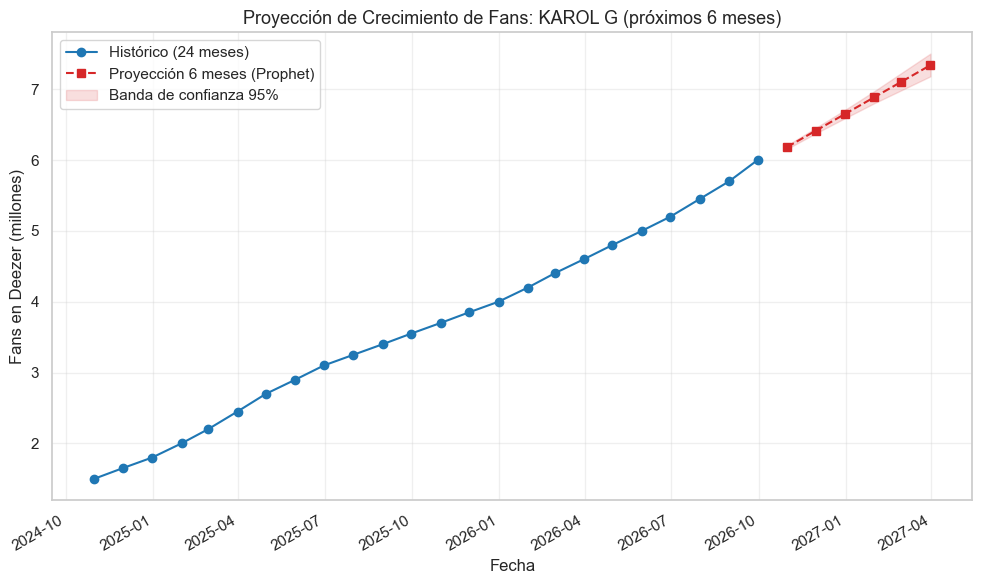

In [11]:
# Gráfico: histórico + proyección + banda de confianza 95%
resultado['fig']


In [12]:
# Comparativa de motores: el fallback sklearn como referencia lineal
import numpy as np
from forecast_fans import HISTORICO_FANS, _sklearn_forecast

y = np.asarray(HISTORICO_FANS, dtype=float)
pred, lo, hi, fechas, engine = _sklearn_forecast(y)
print(f"{engine}: {int(y[-1]):,} fans hoy -> {int(pred[-1]):,} en 6 meses (+{(pred[-1]/y[-1]-1)*100:.1f}%)")
print(f"Prophet: {int(y[-1]):,} fans hoy -> proyección con momentum: +{resultado['crecimiento_6m_pct']}%")
print()
print("Dos lecturas del mismo futuro: Prophet capta el momentum no lineal; sklearn marca la referencia lineal mínima.")


scikit-learn (LinearRegression): 6,000,000 fans hoy -> 6,930,144 en 6 meses (+15.5%)
Prophet: 6,000,000 fans hoy -> proyección con momentum: +22.3%

Dos lecturas del mismo futuro: Prophet capta el momentum no lineal; sklearn marca la referencia lineal mínima.
